# **IUCN distribution - ACUS**

Author: Daning Montaño - Ocampo

Kernel: R

# **1. Packages and libraries**

In [2]:
suppressMessages({
  library(dplyr)
  library(ggplot2)
  library(sf)
  library(iNEXT)
  library(tidyr)
  library(vegan)
  library(tibble)
  library(gstat)
  library(ggplot2)
  library(purrr)
  library(stringr)
  library(bdc)
  library(openxlsx)
  library(units)
  library(terra)
  })
  #library(doParallel)
  #

Warning messages:
1: package ‘dplyr’ was built under R version 4.3.3 
2: package ‘iNEXT’ was built under R version 4.3.3 
3: package ‘tidyr’ was built under R version 4.3.3 
4: package ‘units’ was built under R version 4.3.3 
5: package ‘terra’ was built under R version 4.3.3 


# **2.Load data**

## 2.1. Grids

In [12]:

grids_1km_buffer = st_read("../../../DATOS/SHP/Grids/grid_zamora_ch_buffer_1km.shp")
AOI = st_read("../../../DATOS/SHP/Limites_politicos/Provincia_ZCh_5km_buffer.shp")

Reading layer `grid_zamora_ch_buffer_1km' from data source 
  `C:\PROYECTOS\consultorias\ACUS DIAGNOSTICO\DATOS\SHP\Grids\grid_zamora_ch_buffer_1km.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 15779 features and 5 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 675083.7 ymin: 9444351 xmax: 794083.7 ymax: 9631351
Projected CRS: WGS 84 / UTM zone 17S
Reading layer `Provincia_ZCh_5km_buffer' from data source 
  `C:\PROYECTOS\consultorias\ACUS DIAGNOSTICO\DATOS\SHP\Limites_politicos\Provincia_ZCh_5km_buffer.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 1 feature and 7 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 664270.2 ymin: 9435300 xmax: 802756.4 ymax: 9640425
Projected CRS: WGS 84 / UTM zone 17S


## 2.2. List of distribution files

In [13]:
list_iucn_files = list.files("../../../DATOS/SHP/Biodiversidad/IUCN_distributions")

list_iucn_files_shp = list_iucn_files[grepl("\\.shp$", list_iucn_files)]
list_iucn_files_shp

[1] "amphibians_1.shp" "amphibians_2.shp" "birds_all.shp"    "mammals_1.shp"    "mammals_2.shp"   
[6] "plantas_1.shp"    "plantas_2.shp"    "reptiles_1.shp"   "reptiles_2.shp"  

## 2.3. Red List

In [14]:
iucn_red_list = read.xlsx("../../../DATOS/Datasets/Biodiversidad/tabla_biodiversidad_ecuador_redlists_all_gbif.xlsx")|>
  select(Estado_conservacion,  sci_name_gbif)|>
  mutate(scientificName = sci_name_gbif )|>
  select(-sci_name_gbif)

# **3. Join data**

## 3.1. Join all distributions

In [15]:

# listar shp
list_iucn_files <- list.files(
  "../../../DATOS/SHP/Biodiversidad/IUCN_distributions",
  pattern = "\\.shp$",
  full.names = TRUE
)

# leer, reproyectar a UTM 17S (EPSG:32717) y agregar nombre de archivo
iucn_list <- map(list_iucn_files, function(f) {
  st_read(f, quiet = TRUE) |>
    st_transform(32717) |>
    mutate(source_file = str_remove(basename(f), "\\.shp$"))
})

# unir todo en un solo objeto
iucn_all <- bind_rows(iucn_list)


## 3.2. Add group value

In [16]:
iucn_all <- iucn_all %>%
  dplyr::mutate(
    Group = dplyr::case_when(
      source_file == "birds_all" ~ "Aves",
      source_file == "reptiles_1" ~ "Reptiles",
      source_file == "reptiles_2" ~ "Reptiles",
      source_file == "amphibians_1" ~ "Anfibios",
      source_file == "amphibians_2" ~ "Anfibios",
      source_file == "plantas_1" ~ "Plantas",
      source_file == "plantas_2" ~ "Plantas",
      source_file == "mammals_1" ~ "Mamíferos",
      source_file == "mammals_2" ~ "Mamíferos",
      TRUE ~ NA_character_
    )
  )


# **4.Transform names - GBIF Backbone**

## 4.1 Extract names

In [17]:
sp_plants = iucn_all |>
  dplyr::filter(Group == "Plantas")|>
  pull(sci_name)|>
  unique()|>
  na.omit()



sp_birds = iucn_all |>
  dplyr::filter(Group == "Aves"
  )|>
      pull(sci_name)|>
      unique()|>
        na.omit()


sp_mammals = iucn_all |>
  dplyr::filter(Group == "Mamíferos"
  )|>
      pull(sci_name)|>
      unique()|>
        na.omit()


sp_amphibia = iucn_all |>
  dplyr::filter(Group == "Anfibios"
  )|>
      pull(sci_name)|>
      unique()|>
        na.omit()

sp_squamata = iucn_all |>
  dplyr::filter(Group == "Reptiles"
  )|>
      pull(sci_name)|>
      unique()|>
        na.omit()

## 4.2 Plants

In [18]:
length(sp_plants)

[1] 95

In [19]:
query_names_plants <- bdc_query_names_taxadb(
  sci_name            = sp_plants,
  replace_synonyms    = TRUE,
  suggest_names       = TRUE, 
  suggestion_distance = 0.7,
  db                  = "gbif",
  rank_name           = "Plantae",
  rank                = "kingdom",
  parallel            = 8, # <--- Cambia esto a FALSE
  export_accepted     = FALSE
)


Querying using gbif database version 22.12

                     
 A total of 0 NA was/were found in sci_name.

 95 names queried in 0.2 minutes



In [20]:
query_names_plants = query_names_plants %>%
  select(original_search, distance, notes, taxonID, scientificName, taxonRank,  taxonomicStatus, kingdom,
    phylum, class, order , family,genus, specificEpithet )
notes_sum_gbif = query_names_plants%>%
  group_by(notes)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

notes_sum_gbif

# A tibble: 6 × 3
  notes                                 n  prop
  <chr>                             <int> <dbl>
1 accepted                             86 90.5 
2 accepted | replaceSynonym             5  5.26
3 heterotypic synonym                   1  1.05
4 homotypic synonym                     1  1.05
5 homotypic synonym | wasMisspelled     1  1.05
6 notFound                              1  1.05

In [21]:
query_names_plants =  query_names_plants %>%
  filter(taxonRank %in% c("subspecies", "species"))%>%
  as.data.frame()
head(query_names_plants)

         original_search distance    notes      taxonID         scientificName taxonRank taxonomicStatus
1      Greigia sodiroana       NA accepted GBIF:2693948      Greigia sodiroana   species        accepted
2          Puya compacta       NA accepted GBIF:2696369          Puya compacta   species        accepted
3          Puya obconica       NA accepted GBIF:2696091          Puya obconica   species        accepted
4 Epiphyllum phyllanthus       NA accepted GBIF:5384030 Epiphyllum phyllanthus   species        accepted
5      Opuntia quitensis       NA accepted GBIF:5625287      Opuntia quitensis   species        accepted
6        Espostoa lanata       NA accepted GBIF:7279707        Espostoa lanata   species        accepted
  kingdom       phylum         class          order       family      genus specificEpithet
1 Plantae Tracheophyta    Liliopsida         Poales Bromeliaceae    Greigia       sodiroana
2 Plantae Tracheophyta    Liliopsida         Poales Bromeliaceae       Puya      

In [22]:
dim(query_names_plants)

[1] 91 14

## 4.3. Aves

In [23]:
length(sp_birds)

[1] 893

In [24]:
query_names_aves <- bdc_query_names_taxadb(
  sci_name            = sp_birds,
  replace_synonyms    = TRUE,
  suggest_names       = TRUE, 
  suggestion_distance = 0.7,
  db                  = "gbif",
  rank_name           = "Aves",
  rank                = "class",
  parallel            = 8, # <--- Cambia esto a FALSE
  export_accepted     = FALSE
)


Querying using gbif database version 22.12

                     
 A total of 0 NA was/were found in sci_name.

 893 names queried in 0.1 minutes



In [25]:
query_names_aves = query_names_aves %>%
  select(original_search, distance, notes, taxonID, scientificName, taxonRank,  taxonomicStatus, kingdom,
    phylum, class, order , family,genus, specificEpithet )
notes_sum_aves = query_names_aves%>%
  group_by(notes)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

notes_sum_aves

# A tibble: 5 × 3
  notes                                         n   prop
  <chr>                                     <int>  <dbl>
1 accepted                                    793 88.8  
2 accepted | replaceSynonym                    31  3.47 
3 accepted | wasMisspelled                      1  0.112
4 accepted | wasMisspelled | replaceSynonym     1  0.112
5 homotypic synonym                            67  7.50 

In [26]:
query_names_aves =  query_names_aves %>%
  filter(taxonRank %in% c("subspecies", "species" ))%>%
  filter(taxonomicStatus == "accepted")
query_names_aves

# A tibble: 826 × 14
   original_search   distance notes taxonID scientificName taxonRank taxonomicStatus kingdom phylum class order
   <chr>                <dbl> <chr> <chr>   <chr>          <chr>     <chr>           <chr>   <chr>  <chr> <chr>
 1 Asio clamator           NA acce… GBIF:4… Pseudoscops c… species   accepted        Animal… Chord… Aves  Stri…
 2 Brotogeris pyrrh…       NA acce… GBIF:2… Brotogeris py… species   accepted        Animal… Chord… Aves  Psit…
 3 Campylopterus la…       NA acce… GBIF:2… Campylopterus… species   accepted        Animal… Chord… Aves  Apod…
 4 Cardellina canad…       NA acce… GBIF:6… Cardellina ca… species   accepted        Animal… Chord… Aves  Pass…
 5 Catharus minimus        NA acce… GBIF:2… Catharus mini… species   accepted        Animal… Chord… Aves  Pass…
 6 Chaetocercus bom…       NA acce… GBIF:5… Chaetocercus … species   accepted        Animal… Chord… Aves  Apod…
 7 Coccyzus america…       NA acce… GBIF:2… Coccyzus amer… species   accepted      

## 4.4. Mammals

In [27]:
length(sp_mammals)

[1] 199

In [28]:
query_names_mammals <- bdc_query_names_taxadb(
  sci_name            = sp_mammals,
  replace_synonyms    = TRUE,
  suggest_names       = TRUE, 
  suggestion_distance = 0.7,
  db                  = "gbif",
  rank_name           = "Mammalia",
  rank                = "class",
  parallel            = 8, # <--- Cambia esto a FALSE
  export_accepted     = FALSE
)


Querying using gbif database version 22.12

                     
 A total of 0 NA was/were found in sci_name.

 199 names queried in 0.1 minutes



In [29]:
query_names_mammals= query_names_mammals %>%
   select(original_search, distance, notes, taxonID, scientificName, taxonRank,  taxonomicStatus, kingdom,
     phylum, class, order , family,genus, specificEpithet )
 notes_sum_mammals= query_names_mammals%>%
   group_by(notes)%>%
   count()%>%
   ungroup()%>%
   mutate(prop = (n/sum(n))*100)

notes_sum_mammals

# A tibble: 4 × 3
  notes                         n  prop
  <chr>                     <int> <dbl>
1 accepted                    182 91.5 
2 accepted | replaceSynonym     7  3.52
3 homotypic synonym             4  2.01
4 notFound                      6  3.02

In [30]:
query_names_mammals =  query_names_mammals %>%
  filter(taxonRank %in% c("subspecies", "species" ))%>%
  filter(taxonomicStatus == "accepted")

query_names_mammals

# A tibble: 189 × 14
   original_search   distance notes taxonID scientificName taxonRank taxonomicStatus kingdom phylum class order
   <chr>             <lgl>    <chr> <chr>   <chr>          <chr>     <chr>           <chr>   <chr>  <chr> <chr>
 1 Cuniculus taczan… NA       acce… GBIF:5… Cuniculus tac… species   accepted        Animal… Chord… Mamm… Rode…
 2 Akodon mollis     NA       acce… GBIF:2… Akodon mollis  species   accepted        Animal… Chord… Mamm… Rode…
 3 Artibeus fraterc… NA       acce… GBIF:2… Artibeus frat… species   accepted        Animal… Chord… Mamm… Chir…
 4 Artibeus liturat… NA       acce… GBIF:2… Artibeus litu… species   accepted        Animal… Chord… Mamm… Chir…
 5 Bradypus variega… NA       acce… GBIF:2… Bradypus vari… species   accepted        Animal… Chord… Mamm… Pilo…
 6 Carollia brevica… NA       acce… GBIF:1… Carollia brev… species   accepted        Animal… Chord… Mamm… Chir…
 7 Chiroderma villo… NA       acce… GBIF:2… Chiroderma vi… species   accepted      

## 4.5. Amphibia

In [31]:
length(sp_amphibia)

[1] 163

In [32]:
query_names_amphibia <- bdc_query_names_taxadb(
  sci_name            = sp_amphibia,
  replace_synonyms    = TRUE,
  suggest_names       = TRUE, 
  suggestion_distance = 0.7,
  db                  = "gbif",
  rank_name           = "Amphibia",
  rank                = "class",
  parallel            = 8, # <--- Cambia esto a FALSE
  export_accepted     = FALSE
)


Querying using gbif database version 22.12

                     
 A total of 0 NA was/were found in sci_name.

 163 names queried in 0.2 minutes



In [33]:
query_names_amphibia= query_names_amphibia %>%
  select(original_search, distance, notes, taxonID, scientificName, taxonRank,  taxonomicStatus, kingdom,
    phylum, class, order , family,genus, specificEpithet )
notes_sum_amphibia= query_names_amphibia%>%
  group_by(notes)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

notes_sum_amphibia

# A tibble: 4 × 3
  notes                         n  prop
  <chr>                     <int> <dbl>
1 accepted                    155 95.1 
2 accepted | replaceSynonym     3  1.84
3 accepted | wasMisspelled      3  1.84
4 notFound                      2  1.23

In [34]:
query_names_amphibia =  query_names_amphibia %>%
  filter(taxonRank %in% c("subspecies", "species" ))%>%
  filter(taxonomicStatus == "accepted")

query_names_amphibia

# A tibble: 161 × 14
   original_search   distance notes taxonID scientificName taxonRank taxonomicStatus kingdom phylum class order
   <chr>                <dbl> <chr> <chr>   <chr>          <chr>     <chr>           <chr>   <chr>  <chr> <chr>
 1 Pristimantis bro…       NA acce… GBIF:2… Pristimantis … species   accepted        Animal… Chord… Amph… Anura
 2 Pristimantis bal…       NA acce… GBIF:2… Pristimantis … species   accepted        Animal… Chord… Amph… Anura
 3 Rhinella festae         NA acce… GBIF:5… Rhinella fest… species   accepted        Animal… Chord… Amph… Anura
 4 Pristimantis pho…       NA acce… GBIF:2… Pristimantis … species   accepted        Animal… Chord… Amph… Anura
 5 Pristimantis pro…       NA acce… GBIF:2… Pristimantis … species   accepted        Animal… Chord… Amph… Anura
 6 Pristimantis vid…       NA acce… GBIF:2… Pristimantis … species   accepted        Animal… Chord… Amph… Anura
 7 Caecilia disossea       NA acce… GBIF:5… Caecilia diso… species   accepted      

## 4.6. Reptile

In [35]:
length(sp_squamata)

[1] 55

In [36]:
query_names_squamata <- bdc_query_names_taxadb(
  sci_name            = sp_squamata,
  replace_synonyms    = TRUE,
  suggest_names       = TRUE, 
  suggestion_distance = 0.7,
  db                  = "gbif",
  rank_name           = "Squamata",
  rank                = "class",
  parallel            = 8, # <--- Cambia esto a FALSE
  export_accepted     = FALSE
)



Querying using gbif database version 22.12

                     
 A total of 0 NA was/were found in sci_name.

 55 names queried in 0.1 minutes



In [37]:
query_names_squamata= query_names_squamata %>%
  select(original_search, distance, notes, taxonID, scientificName, taxonRank,  taxonomicStatus, kingdom,
    phylum, class, order , family,genus, specificEpithet )
notes_sum_squamata= query_names_squamata%>%
  group_by(notes)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

notes_sum_squamata

# A tibble: 2 × 3
  notes        n  prop
  <chr>    <int> <dbl>
1 accepted    54 98.2 
2 notFound     1  1.82

In [38]:
query_names_squamata =  query_names_squamata %>%
  filter(taxonRank %in% c("subspecies", "species" ))%>%
  filter(taxonomicStatus == "accepted")

query_names_squamata

# A tibble: 54 × 14
   original_search   distance notes taxonID scientificName taxonRank taxonomicStatus kingdom phylum class order
   <chr>             <lgl>    <chr> <chr>   <chr>          <chr>     <chr>           <chr>   <chr>  <chr> <chr>
 1 Paleosuchus palp… NA       acce… GBIF:2… Paleosuchus p… species   accepted        Animal… Chord… Rept… Croc…
 2 Lachesis muta     NA       acce… GBIF:8… Lachesis muta  species   accepted        Animal… Chord… Rept… Squa…
 3 Anilius scytale   NA       acce… GBIF:2… Anilius scyta… species   accepted        Animal… Chord… Rept… Squa…
 4 Bothrocophias lo… NA       acce… GBIF:1… Bothrocophias… species   accepted        Animal… Chord… Rept… Squa…
 5 Atractus bocourti NA       acce… GBIF:5… Atractus boco… species   accepted        Animal… Chord… Rept… Squa…
 6 Dipsas pavonina   NA       acce… GBIF:5… Dipsas pavoni… species   accepted        Animal… Chord… Rept… Squa…
 7 Dipsas peruana    NA       acce… GBIF:5… Dipsas peruana species   accepted       

## 4.7. Join Querys

In [39]:
all_querys = rbind(query_names_plants,query_names_aves,query_names_amphibia,query_names_mammals, query_names_squamata)


In [40]:

tax_update <- all_querys |>
  select(
    original_search,
    taxonID,
    scientificName,
    taxonRank,
    taxonomicStatus,
    kingdom,
    phylum,
    class,
    order,
    family,
    genus,
    specificEpithet
  ) |>
  rename(sci_name = original_search)


## 4.8 Replace taxonomical data

In [41]:
iucn_all_join = iucn_all |>
  select(
    id_no,
    sci_name,
    Group
  ) |>
  left_join(tax_update, by = c("sci_name" = "sci_name")) |>
  filter(!is.na(specificEpithet)) |>
  mutate(
    area_km2 = set_units(st_area(geometry), km^2) |> drop_units()
  )|>
  select(-sci_name)

# **5. Red List - Ecuador**

In [42]:
iucn_all_join = iucn_all_join |>
  left_join(iucn_red_list, by = c("scientificName"))


Warning message:
In sf_column %in% names(g) :
  Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1052 of `x` matches multiple rows in `y`.
ℹ Row 7177 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship = "many-to-many"` to silence this warning.


# **6. Weight per species (endemism)**

In [43]:
iucn_all_join$Weight = 1/iucn_all_join$area_km2

# **7. Distribution to grids**

## 7.1. Extract sp by grid ids

In [44]:

# Igualar CRS
if (st_crs(AOI) != st_crs(iucn_all_join)) {
  AOI <- st_transform(AOI, st_crs(iucn_all_join))
}

if (st_crs(grids_1km_buffer) != st_crs(iucn_all_join)) {
  grids_1km_buffer <- st_transform(grids_1km_buffer, st_crs(iucn_all_join))
}

# Unir AOI en una sola geometría
AOI <- st_union(AOI)

# Arreglar geometrías inválidas solo si hace falta
iucn_all_join <- st_make_valid(iucn_all_join)
grids_1km_buffer <- st_make_valid(grids_1km_buffer)
AOI <- st_make_valid(AOI)

# Filtrar especies al AOI
iucn_aoi <- st_filter(
  iucn_all_join %>% select(scientificName, geometry),
  AOI,
  .predicate = st_intersects
)

# Filtrar grids al AOI
grids_aoi <- st_filter(
  grids_1km_buffer %>% select(grid_id = id, geometry),
  AOI,
  .predicate = st_intersects
)

# Relación espacial grid -> especies
idx <- st_intersects(grids_aoi, iucn_aoi)

# Lista nombrada: cada grid_id tiene varias especies posibles
species_by_grid <- setNames(
  lapply(idx, function(i) unique(iucn_aoi$scientificName[i])),
  grids_aoi$grid_id
)

# Quitar grids vacíos
species_by_grid <- species_by_grid[lengths(species_by_grid) > 0]

In [35]:
grid_species_df <- stack(species_by_grid)
names(grid_species_df) <- c("scientificName", "grid_id")
head(grid_species_df)

               scientificName grid_id
1       Leptodactylus wagneri   14262
2 Dendropsophus sarayacuensis   14262
3     Pristimantis versicolor   14262
4   Dendropsophus rhodopeplus   14262
5        Phyllomedusa tarsius   14262
6                 Boana boans   14262

## 7.2. Join with other species data

In [36]:
iucn_all_join_df_unique <- iucn_all_join %>%
  as.data.frame() %>%
  select(id_no,taxonRank,kingdom,  phylum,class, order,  family, genus, specificEpithet, scientificName,area_km2,Weight, Estado_conservacion,Group)%>%
  group_by(scientificName) %>%
  summarise(
    id_no = first(id_no),
    taxonRank = first(taxonRank),
    kingdom = first(kingdom),
    phylum = first(phylum),
    class = first(class),
    order = first(order),
    family = first(family),
    genus = first(genus),
    specificEpithet = first(specificEpithet),
    area_km2 = first(area_km2),
    Weight = first(Weight),
    Estado_conservacion = first(Estado_conservacion),
    Group = first(Group),
    .groups = "drop"
  )

grid_species_df_complete <- grid_species_df %>%
  left_join(iucn_all_join_df_unique, by = "scientificName")

In [50]:
head(grid_species_df_complete)

               scientificName grid_id id_no taxonRank  kingdom   phylum
1       Leptodactylus wagneri   14262 57175   species Animalia Chordata
2 Dendropsophus sarayacuensis   14262 55644   species Animalia Chordata
3     Pristimantis versicolor   14262 57039   species Animalia Chordata
4   Dendropsophus rhodopeplus   14262 55625   species Animalia Chordata
5        Phyllomedusa tarsius   14262 55864   species Animalia Chordata
6                 Boana boans   14262 55415   species Animalia Chordata
     class order          family         genus specificEpithet    area_km2
1 Amphibia Anura Leptodactylidae Leptodactylus         wagneri 1078695.839
2 Amphibia Anura         Hylidae Dendropsophus   sarayacuensis 3688704.428
3 Amphibia Anura  Craugastoridae  Pristimantis      versicolor    6971.381
4 Amphibia Anura         Hylidae Dendropsophus     rhodopeplus 2650116.513
5 Amphibia Anura Phyllomedusidae  Phyllomedusa         tarsius 2314588.099
6 Amphibia Anura         Hylidae         Boana

In [51]:
write.csv(grid_species_df_complete,"../../../DATOS/Datasets/Biodiversidad/grid_species_IUCN.csv")

# **8. Generate summary by grid_id - Example**

## 8.1. Load data

In [8]:
grid_species_df_complete= read.csv("../../../DATOS/Datasets/Biodiversidad/grid_species_IUCN.csv")

Unique values of groups

We only selected mammals, plants, reptiles

In [9]:
unique(grid_species_df_complete$Group)

[1] "Anfibios"  "Aves"      "Mamíferos" "Plantas"   "Reptiles" 

## 8.2. Generate mammals raster

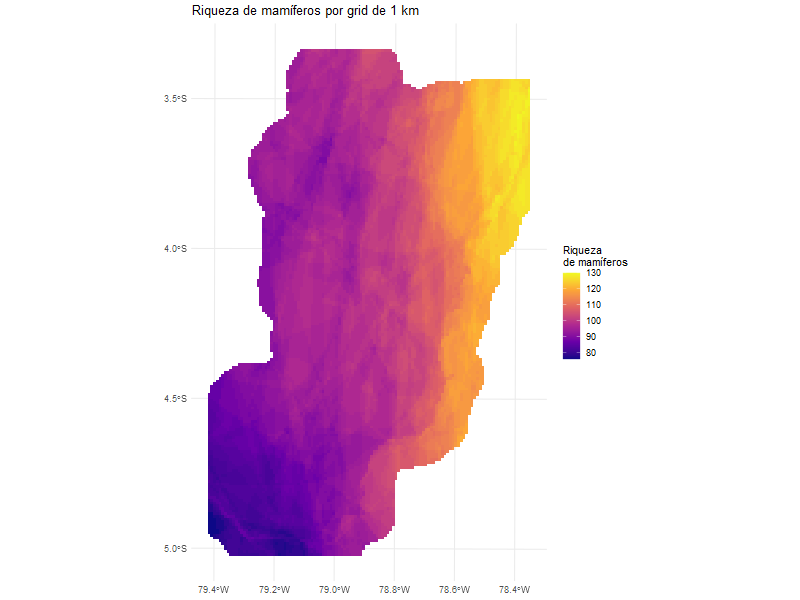

In [10]:

# Filtrar solo aves
mammals_species <- grid_species_df_complete %>%
  filter(Group == "Mamíferos") %>%
  mutate(
    grid_id = as.numeric(as.character(grid_id))
  )

# Calcular riqueza por grid
mammals_by_grid <- mammals_species %>%
  group_by(grid_id) %>%
  summarise(
    mammals_richness = n_distinct(scientificName),
    .groups = "drop"
  )

# Asegurar mismo tipo en el shapefile
grids_1km_buffer <- grids_1km_buffer %>%
  mutate(
    id = as.numeric(id)
  )

# Unir riqueza al grid
grids_mammals_richness <- grids_1km_buffer %>%
  left_join(mammals_by_grid, by = c("id" = "grid_id")) %>%
  mutate(
    mammals_richness = ifelse(is.na(mammals_richness), 0, mammals_richness)
  )

# Mapa
ggplot(grids_mammals_richness) +
  geom_sf(aes(fill = mammals_richness), color = NA) +
  scale_fill_viridis_c(
    option = "plasma",
    name = "Riqueza\nde mamíferos"
  ) +
  labs(
    title = "Riqueza de mamíferos por grid de 1 km"
  ) +
  theme_minimal()

Raster

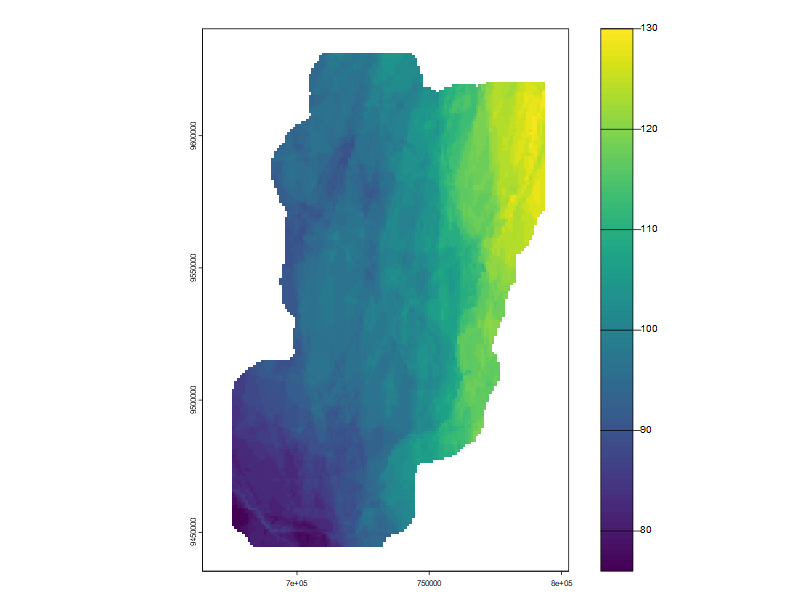

In [11]:
# 1. Convertir sf a SpatVector
grid_vect <- vect(grids_mammals_richness)

# 2. Crear raster base con resolución de 1000 m
r_base <- rast(
  ext(AOI),
  resolution = 1000,
  crs = crs(grid_vect)
)

# 3. Rasterizar usando el campo deseado
r_1km_mammals <- rasterize(grid_vect, r_base, field = "mammals_richness")

# 4. Ver resultado
plot(r_1km_mammals)

## 8.3 Generate plants

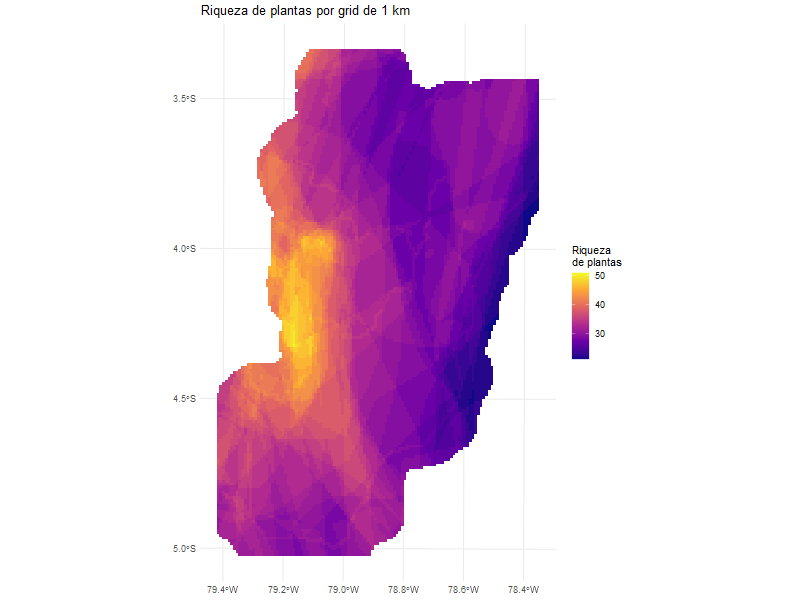

In [20]:

# Filtrar solo aves
plantas_species <- grid_species_df_complete %>%
  filter(Group == "Plantas") %>%
  mutate(
    grid_id = as.numeric(as.character(grid_id))
  )

# Calcular riqueza por grid
plantas_species_by_grid <- plantas_species %>%
  group_by(grid_id) %>%
  summarise(
    plantas_richness = n_distinct(scientificName),
    .groups = "drop"
  )

# Asegurar mismo tipo en el shapefile
grids_1km_buffer <- grids_1km_buffer %>%
  mutate(
    id = as.numeric(id)
  )

# Unir riqueza al grid
grids_plants_richness <- grids_1km_buffer %>%
  left_join(plantas_species_by_grid, by = c("id" = "grid_id")) %>%
  mutate(
    plantas_richness = ifelse(is.na(plantas_richness), 0, plantas_richness)
  )

# Mapa
ggplot(grids_plants_richness) +
  geom_sf(aes(fill = plantas_richness), color = NA) +
  scale_fill_viridis_c(
    option = "plasma",
    name = "Riqueza\nde plantas"
  ) +
  labs(
    title = "Riqueza de plantas por grid de 1 km"
  ) +
  theme_minimal()

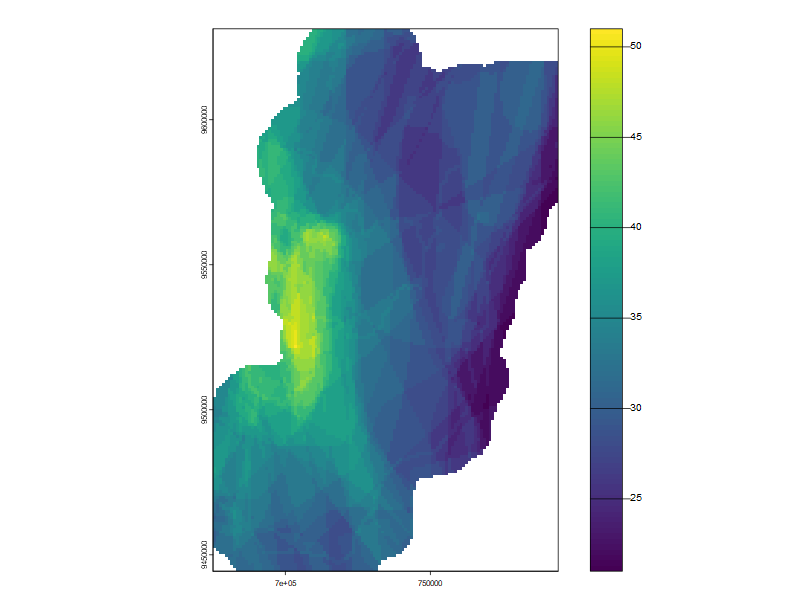

In [22]:
# 1. Convertir sf a SpatVector
grid_vect <- vect(grids_plants_richness)

# 2. Crear raster base con resolución de 1000 m
r_base <- rast(
  ext(grid_vect),
  resolution = 1000,
  crs = crs(grid_vect)
)

# 3. Rasterizar usando el campo deseado
r_1km_plantas <- rasterize(grid_vect, r_base, field = "plantas_richness")

# 4. Ver resultado
plot(r_1km_plantas)

Raster

## 8.4. Generate reptiles

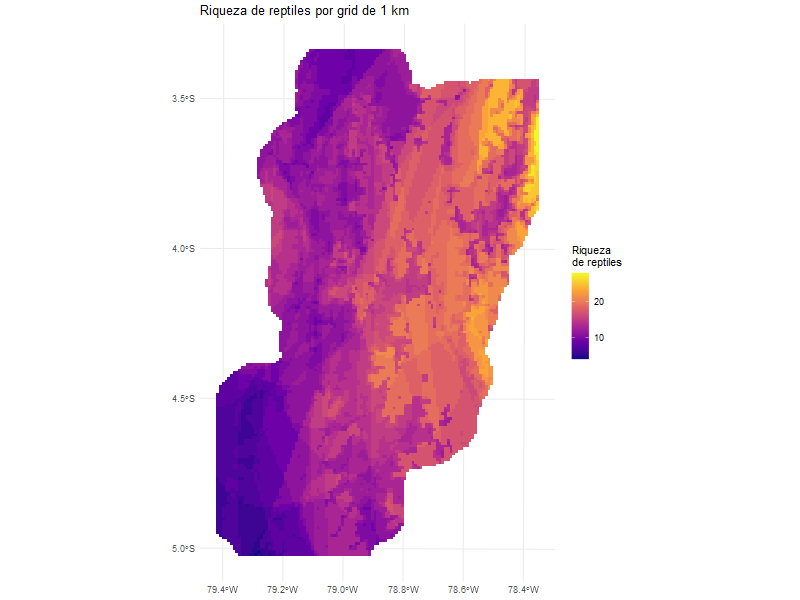

In [24]:

# Filtrar solo aves
reptiles_species <- grid_species_df_complete %>%
  filter(Group == "Reptiles") %>%
  mutate(
    grid_id = as.numeric(as.character(grid_id))
  )

# Calcular riqueza por grid
reptiles_species_by_grid <- reptiles_species %>%
  group_by(grid_id) %>%
  summarise(
    reptiles_richness = n_distinct(scientificName),
    .groups = "drop"
  )

# Asegurar mismo tipo en el shapefile
grids_1km_buffer <- grids_1km_buffer %>%
  mutate(
    id = as.numeric(id)
  )

# Unir riqueza al grid
grids_reptiles_richness <- grids_1km_buffer %>%
  left_join(reptiles_species_by_grid, by = c("id" = "grid_id")) %>%
  mutate(
    reptiles_richness = ifelse(is.na(reptiles_richness), 0, reptiles_richness)
  )

# Mapa
ggplot(grids_reptiles_richness) +
  geom_sf(aes(fill = reptiles_richness), color = NA) +
  scale_fill_viridis_c(
    option = "plasma",
    name = "Riqueza\nde reptiles"
  ) +
  labs(
    title = "Riqueza de reptiles por grid de 1 km"
  ) +
  theme_minimal()

Raster

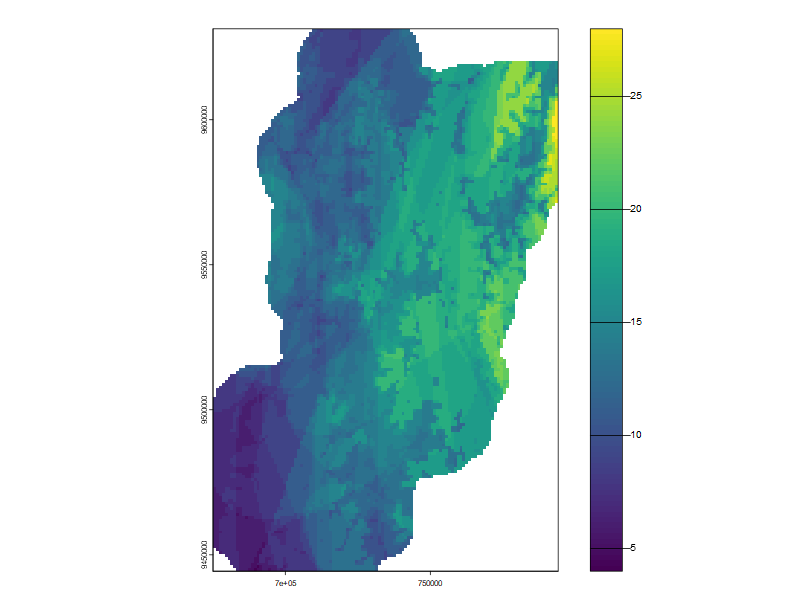

In [25]:
# 1. Convertir sf a SpatVector
grid_vect <- vect(grids_reptiles_richness)

# 2. Crear raster base con resolución de 1000 m
r_base <- rast(
  ext(grid_vect),
  resolution = 1000,
  crs = crs(grid_vect)
)

# 3. Rasterizar usando el campo deseado
r_1km_reptiles <- rasterize(grid_vect, r_base, field = "reptiles_richness")

# 4. Ver resultado
plot(r_1km_reptiles)

# **9. Export**

In [27]:
## mammals
writeRaster(
  r_1km_mammals,
  "../../../DATOS/Raster/Richness/Mammals_richness_z_ch.tif",
  filetype = "GTiff",
  gdal = c("COMPRESS=LZW"),
  overwrite = TRUE
)

## plants

writeRaster(
  r_1km_plantas,
  "../../../DATOS/Raster/Richness/Plants_richness_z_ch.tif",
  filetype = "GTiff",
  gdal = c("COMPRESS=LZW"),
  overwrite = TRUE
)

## reptiles

writeRaster(
  r_1km_reptiles,
  "../../../DATOS/Raster/Richness/Reptiles_richness_z_ch.tif",
  filetype = "GTiff",
  gdal = c("COMPRESS=LZW"),
  overwrite = TRUE
)